Escolha a função de demanda:
1. Linear
2. Exponencial
3. Quadrática
4. Elasticidade Constante
5. Logarítmica
6. Potencial
Digite o número da função de demanda: 6
Máximo encontrado em q_1 = 99.75 com lucro = 599.75


<ipython-input-6-8bf9b01f38ad>:22: RuntimeWarning: divide by zero encountered in scalar divide
  return A / q**b
<ipython-input-6-8bf9b01f38ad>:27: RuntimeWarning: invalid value encountered in scalar multiply
  return p_q * q1 - c * q1


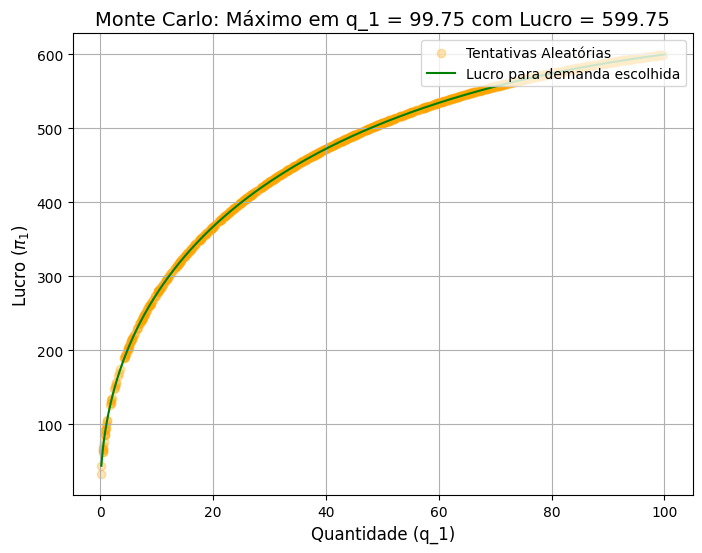

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Funções de demanda
def demanda_linear(q, A, b):
    return A - b * q

def demanda_exponencial(q, A, b):
    return A * np.exp(-b * q)

def demanda_quadratica(q, A, b):
    return A - b * q**2

def demanda_elasticidade_constante(q, A, b):
    return A * q**(-b)

def demanda_logaritmica(q, A, b):
    return A - b * np.log(q)

def demanda_potencial(q, A, b):
    return A / q**b

# Função de lucro adaptada
def pi_1(q1, demanda_func, A, b, c):
    p_q = demanda_func(q1, A, b)
    return p_q * q1 - c * q1

# Monte Carlo method to find the maximum of the profit function
def monte_carlo_maximization(demanda_func, A, b, c, num_tentativas):
    best_q1 = None
    max_profit = float('-inf')
    q1_values = []
    profit_values = []

    for _ in range(num_tentativas):
        # Generate a random q1 in the range [0, 100]
        q1 = random.uniform(0, 100)
        profit = pi_1(q1, demanda_func, A, b, c)

        # Store values for plotting
        q1_values.append(q1)
        profit_values.append(profit)

        # Update if this is the maximum profit found
        if profit > max_profit:
            max_profit = profit
            best_q1 = q1

    return best_q1, max_profit, q1_values, profit_values

# Menu para escolher a função de demanda
def escolher_funcao_demanda():
    print("Escolha a função de demanda:")
    print("1. Linear")
    print("2. Exponencial")
    print("3. Quadrática")
    print("4. Elasticidade Constante")
    print("5. Logarítmica")
    print("6. Potencial")

    escolha = int(input("Digite o número da função de demanda: "))

    if escolha == 1:
        b = 1
        return demanda_linear, b
    elif escolha == 2:
        b = 0.05
        return demanda_exponencial, b
    elif escolha == 3:
        b = 0.02
        return demanda_quadratica, b
    elif escolha == 4:
        b = 0.5
        return demanda_elasticidade_constante, b
    elif escolha == 5:
        b = 10
        return demanda_logaritmica, b
    elif escolha == 6:
        b = 0.5
        return demanda_potencial, b
    else:
        print("Escolha inválida, usando demanda linear.")
        return demanda_linear

# Defina os parâmetros A, b e c
A = 100
# b = 1
c = 4
num_tentativas = 1000

# Escolher a função de demanda
demanda_func, b = escolher_funcao_demanda()

# Execute a função de maximização Monte Carlo
best_q1, max_profit, q1_values, profit_values = monte_carlo_maximization(demanda_func, A, b, c, num_tentativas)

# Saída do resultado
print(f"Máximo encontrado em q_1 = {best_q1:.2f} com lucro = {max_profit:.2f}")

# Plotar os pontos aleatórios usados na busca Monte Carlo
q1 = np.linspace(0, 100, 500)
pi_1_values = [pi_1(q, demanda_func, A, b, c) for q in q1]

plt.figure(figsize=(8, 6))
plt.scatter(q1_values, profit_values, alpha=0.3, label='Tentativas Aleatórias', color='orange')
plt.plot(q1, pi_1_values, label=f'Lucro para demanda escolhida', color='green')
plt.title(f'Monte Carlo: Máximo em q_1 = {best_q1:.2f} com Lucro = {max_profit:.2f}', fontsize=14)
plt.xlabel('Quantidade (q_1)', fontsize=12)
plt.ylabel('Lucro ($\pi_1$)', fontsize=12)
plt.grid(True)
plt.legend(loc='upper right')

# Exibir o gráfico
plt.show()
